In [121]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)


In [122]:
df = pd.read_csv("Bengaluru_House_Data.csv")


In [123]:
df.head()


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [124]:
df.shape


(13320, 9)

In [125]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [126]:
df.describe()


,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [127]:
# Missing values
df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [128]:
# Drop high missing Column

df.drop(columns=["society"], inplace=True)


In [129]:
# Handle missing Values

df["bath"] = df["bath"].fillna(df["bath"].median())
df["balcony"] = df["balcony"].fillna(df["balcony"].median())
df = df.dropna(subset=["location"])


In [130]:
# Clean & Transform SIZE Column

df["size"] = df["size"].str.extract("(\d+)").astype(float)


In [131]:
#Clean total_sqft
#Function to Convert Ranges to Mean

def convert_sqft(value):
    try:
        if "-" in value:
            a, b = value.split("-")
            return (float(a) + float(b)) / 2
        return float(value)
    except:
        return np.nan






In [132]:
df["total_sqft"] = df["total_sqft"].apply(convert_sqft)


In [133]:
df.dropna(subset=["total_sqft"], inplace=True)


In [134]:
#Feature Engineering: Price per Sqft (Unique Touch)

df["price_per_sqft"] = (df["price"] * 100000) / df["total_sqft"]


In [135]:
#Remove Obvious Outliers

df = df[df["total_sqft"] > 300]
df = df[df["price_per_sqft"] < df["price_per_sqft"].quantile(0.99)]


In [136]:
df.shape


(13127, 9)

In [137]:
df.isnull().sum()


area_type          0
availability       0
location           0
size              16
total_sqft         0
bath               0
balcony            0
price              0
price_per_sqft     0
dtype: int64

In [138]:
df.head(10)


,area_type,availability,location,size,total_sqft,bath,balcony,price,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2.0,1056.0,2.0,1.0,39.07,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4.0,2600.0,5.0,3.0,120.00,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3.0,1440.0,2.0,3.0,62.00,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3.0,1521.0,3.0,1.0,95.00,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2.0,1200.0,2.0,1.0,51.00,4250.000000
5,Super built-up Area,Ready To Move,Whitefield,2.0,1170.0,2.0,1.0,38.00,3247.863248
6,Super built-up Area,18-May,Old Airport Road,4.0,2732.0,4.0,2.0,204.00,7467.057101
7,Super built-up Area,Ready To Move,Rajaji Nagar,4.0,3300.0,4.0,2.0,600.00,18181.818182
8,Super built-up Area,Ready To Move,Marathahalli,3.0,1310.0,3.0,1.0,63.25,4828.244275
10,Super built-up Area,18-Feb,Whitefield,3.0,1800.0,2.0,2.0,70.00,3888.888889


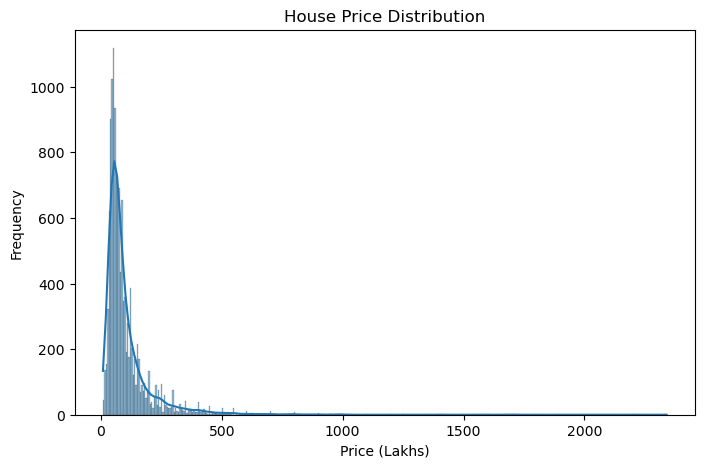

In [139]:
# Target Variable Analysis (Price Distribution)

plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Frequency")
plt.show()


In [140]:
# Price Categories (Unique Angle ⭐)

df["price_category"] = pd.cut(
    df["price"],
    bins=[0, 50, 100, 150, 300],
    labels=["Affordable", "Mid-Range", "Premium", "Luxury"]
)




In [141]:
df["price_category"].value_counts()


price_category
Mid-Range     5691
Affordable    3496
Premium       1829
Luxury        1500
Name: count, dtype: int64

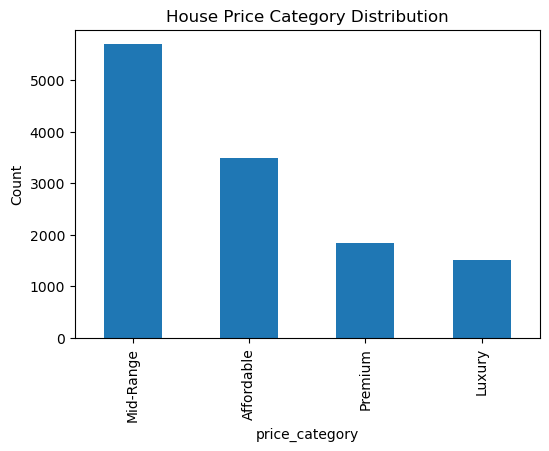

In [142]:
# Target Distribution – Bar & Donut Chart

df["price_category"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="House Price Category Distribution"
)
plt.ylabel("Count")
plt.show()


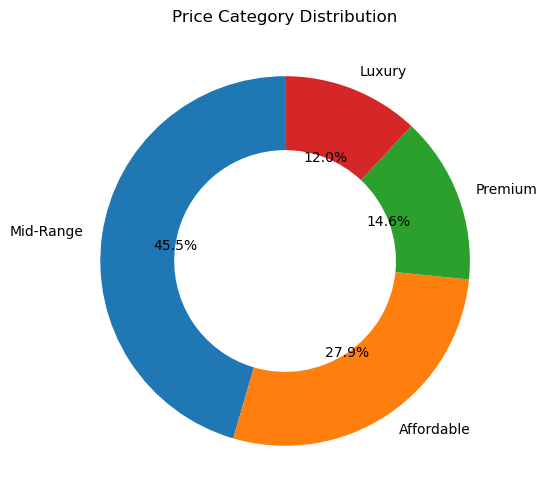

In [143]:
# Donut Chart (Streamlit-friendly)

price_counts = df["price_category"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    price_counts,
    labels=price_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)
plt.title("Price Category Distribution")
plt.show()


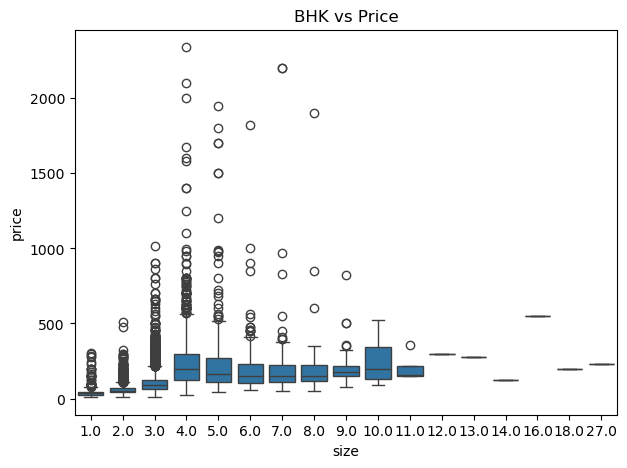

In [144]:
#🏠 Size (BHK) vs Price

plt.figure(figsize=(7,5))
sns.boxplot(x="size", y="price", data=df)
plt.title("BHK vs Price")
plt.show()



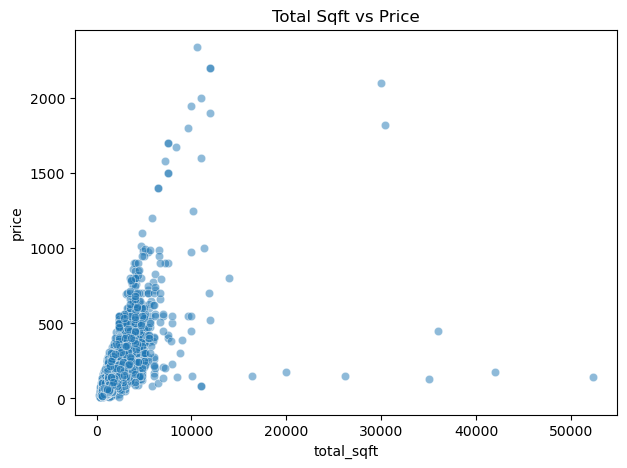

In [145]:
# Total Sqft vs Price

plt.figure(figsize=(7,5))
sns.scatterplot(x="total_sqft", y="price", data=df, alpha=0.5)
plt.title("Total Sqft vs Price")
plt.show()


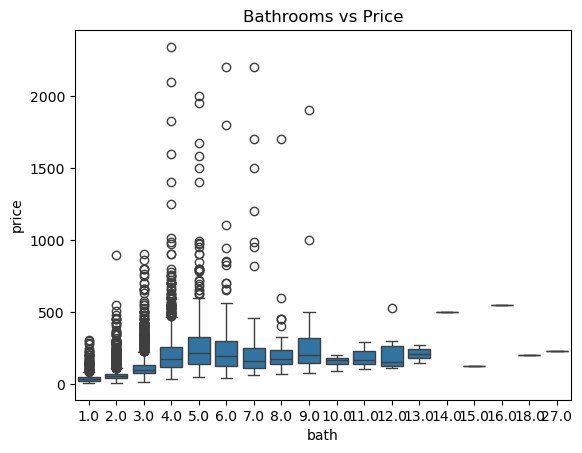

In [146]:
# 🛁 Bathrooms vs Price

sns.boxplot(x="bath", y="price", data=df)
plt.title("Bathrooms vs Price")
plt.show()


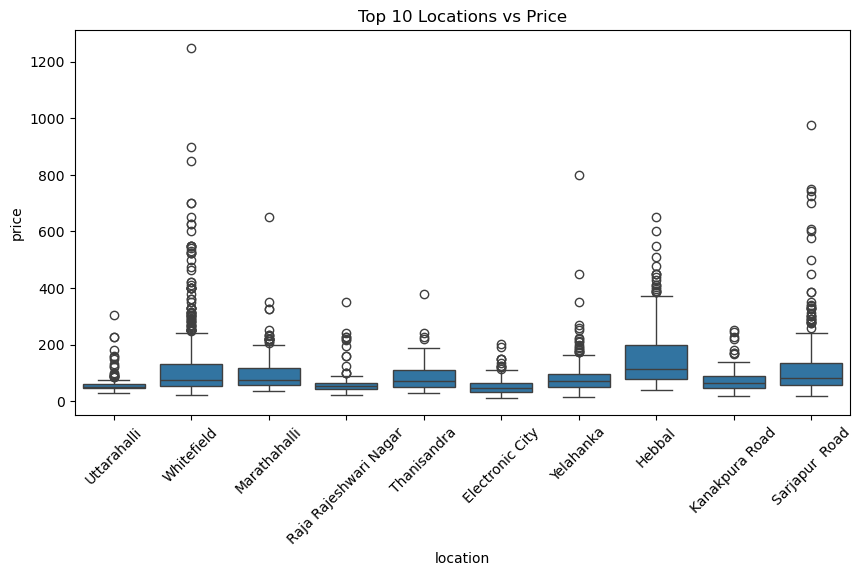

In [147]:
# Location Analysis (Top 10 Locations Only)

top_locations = df["location"].value_counts().head(10).index
loc_df = df[df["location"].isin(top_locations)]

plt.figure(figsize=(10,5))
sns.boxplot(x="location", y="price", data=loc_df)
plt.xticks(rotation=45)
plt.title("Top 10 Locations vs Price")
plt.show()



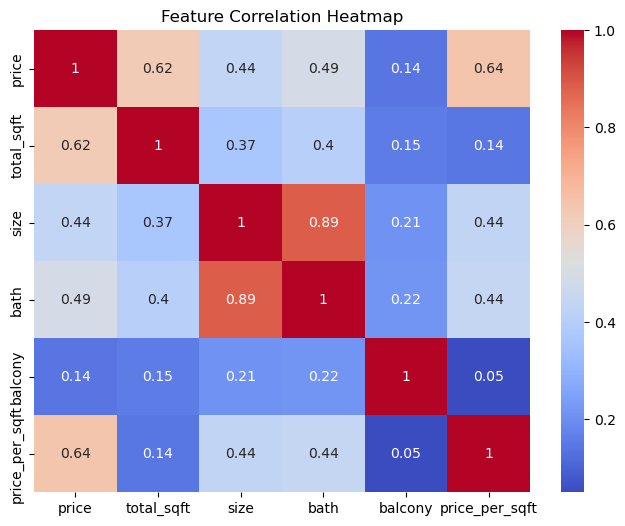

In [148]:
# Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(
    df[["price", "total_sqft", "size", "bath", "balcony", "price_per_sqft"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.show()


In [149]:
# Statistical Summary (EDA + Stats Link)

df.groupby("price_category")["price"].describe()


C:\Users\VISHNU\AppData\Local\Temp\ipykernel_10656\3377076119.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_category")["price"].describe()


,count,mean,std,min,25%,50%,75%,max
price_category,,,,,,,,
Affordable,3496.0,38.856280,8.832077,8.44,34.00,40.39,45.840,50.0
Mid-Range,5691.0,71.552758,14.167157,50.06,59.78,69.76,82.755,100.0
Premium,1829.0,124.966102,14.516739,101.00,112.00,125.00,136.000,150.0
Luxury,1500.0,211.182743,42.650632,151.00,175.00,200.00,245.000,300.0


In [150]:
# Drop EDA-Only Columns

df_model = df.drop(columns=["price_category"])



In [151]:
# Define Features (X) and Target (y)

X = df_model.drop(columns=["price"])
y = df_model["price"]


In [152]:
# Identify Numerical & Categorical Features

num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

num_features, cat_features


(Index(['size', 'total_sqft', 'bath', 'balcony', 'price_per_sqft'], dtype='object'),
 Index(['area_type', 'availability', 'location'], dtype='object'))

In [153]:
# Handle High Cardinality (Unique Touch)
#

location_counts = df_model["location"].value_counts()
rare_locations = location_counts[location_counts < 10].index

df_model["location"] = df_model["location"].apply(
    lambda x: "Other" if x in rare_locations else x
)


In [154]:
#Reduce rare locations

location_counts = df_model["location"].value_counts()
rare_locations = location_counts[location_counts < 10].index

df_model["location"] = df_model["location"].apply(
    lambda x: "Other" if x in rare_locations else x
)


In [155]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["price"])
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [156]:
# Build Preprocessing Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer



In [157]:
# Numerical Pipeline


num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])



In [158]:
#Categorical Pipeline

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


In [159]:
#Combine Pipelines

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])


In [160]:
#Final Prepared Data (Preview)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)


In [161]:
X_train_prepared.shape


(10501, 337)

In [162]:
#Import Required Models & Metrics

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline


In [163]:
#Create Optimized Pipeline
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_pred)

baseline_r2



0.708173356072989

In [164]:
param_grid = {
    "model__n_estimators": [50, 100],        # small but effective
    "model__max_depth": [None, 10],          # bias–variance control
    "model__min_samples_split": [2, 5]
}




In [165]:
#Run GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    verbose=1
)

grid_search.fit(X_train, y_train)



Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['size', 'total_sqft', 'bath', 'balcony', 'price_per_sqft'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         Index(['area_type', 'availability', 'location'], dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(n_jobs=-1,
                                                              random_state=42))]),
             param_grid={'model__max_depth': [None, 10],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [50, 100]},
             scoring='r2', verbose=1)

In [166]:
#Extract Best Model
best_model = grid_search.best_estimator_
grid_search.best_params_




{'model__max_depth': 10,
 'model__min_samples_split': 5,
 'model__n_estimators': 100}

In [167]:
#Evaluate Tuned Model

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_test_pred = best_model.predict(X_test)

final_r2 = r2_score(y_test, y_test_pred)
final_mae = mean_absolute_error(y_test, y_test_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

final_r2, final_mae, final_rmse





(0.9724805506598921, 2.5460867786207677, np.float64(19.430061388184605))

In [168]:
#Evaluate Train vs Test Performance

# Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

# R2 Scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

train_r2, test_r2




(0.9959202616699395, 0.9724805506598921)

In [169]:
#Compare with Baseline Model

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_r2 = r2_score(y_test, baseline_pred)
baseline_r2



0.708173356072989

In [170]:
#Save Final Model & Preprocessor

import joblib

joblib.dump(best_model, "final_house_price_model.pkl")



['final_house_price_model.pkl']

In [171]:
#Create Prediction File#
#Create dataframe of predictions

pred_df = pd.DataFrame({
    "Actual_Price": y_test,
    "Predicted_Price": y_test_pred
})

pred_df.head()





,Actual_Price,Predicted_Price
12680,425.00,423.960597
3341,60.00,59.334078
11637,62.15,61.558637
9634,55.00,53.691198
13023,98.00,97.194672


In [172]:
#Save Predictions to CSV

pred_df.to_csv("house_price_predictions.csv", index=False)


In [173]:
#Evaluation Metrics Summary Table

metrics_summary = pd.DataFrame({
    "Metric": ["Train R2", "Test R2", "RMSE"],
    "Value": [
        train_r2,
        test_r2,
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ]
})

metrics_summary





,Metric,Value
0,Train R2,0.995920
1,Test R2,0.972481
2,RMSE,19.430061


In [174]:
#Save Metrics Report

metrics_summary.to_csv("model_metrics.csv", index=False)


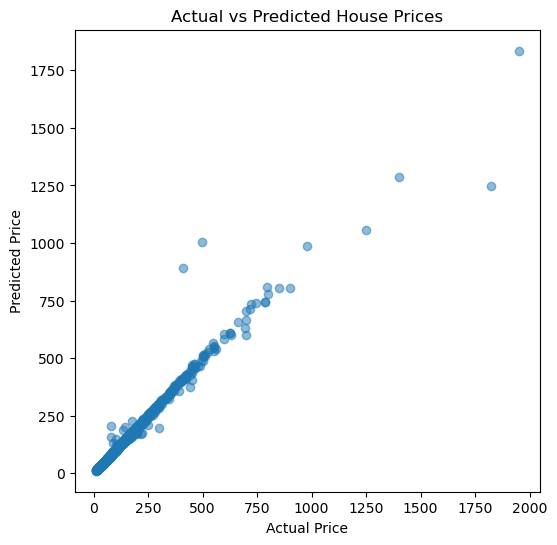

In [175]:
#Visualization: Actual vs Predicted

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()



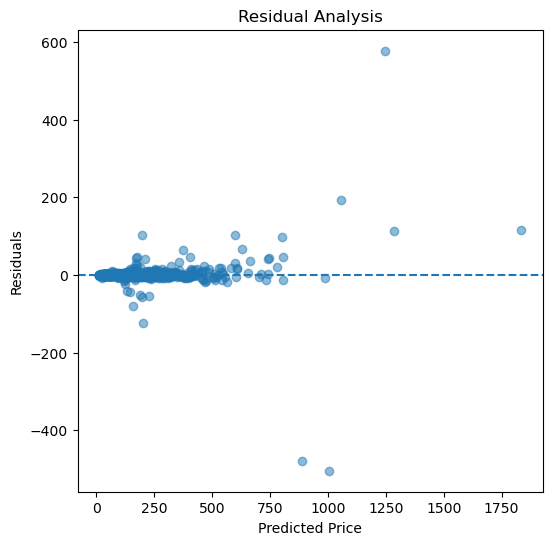

In [176]:
#Residual Plot (Error Analysis)

residuals = y_test - y_test_pred

plt.figure(figsize=(6,6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()



In [177]:
#Feature Importance (Random Forest)

model = best_model.named_steps["model"]

importances = model.feature_importances_

feature_names = best_model.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(10)



,Feature,Importance
1,num__total_sqft,0.640322
4,num__price_per_sqft,0.335739
164,cat__location_Dodsworth Layout,0.016076
85,cat__availability_Ready To Move,0.002906
36,cat__availability_18-Jul,0.000951
3,num__balcony,0.000837
2,num__bath,0.000688
0,num__size,0.000516
7,cat__area_type_Plot Area,0.000334
321,cat__location_Ulsoor,0.000253


In [182]:
#Save Feature Importance

feature_importance_df.to_csv(
    "feature_importance.csv", index=False
)

